In [1]:
from aisam.model import models
import numpy as np
import matplotlib.pyplot as plt
from aisam.model import sims
from aisam.utils import aux
import dill

In [2]:
import json

params = {}
params['delta'] = 0.01
params['alpha'] = 1
params['beta'] = 1
params['k'] = 0.4851
params['k_tet'] = 1
params['h1'] = 2.3435*0.0303
params['h2'] = 0.0303
params['tau_delay'] = 12
params['n']=3.6
params['n_tet'] = 2
params['c2'] = 0.0631
params['t_max'] = 960
params['sampling'] = 10

address = '/Users/hossein/Documents/Projects/RoSAM/'
aux.save_params(params,address)
num_realizations = 3

In [45]:


t_max = 960 #16 h
num_cells = 100
stims = {}

for i in range(num_cells):
    np.random.seed(10*i+10)
    if i<500:
        stims[f'cell {i+1}'] = aux.random_stim_maker(int((t_max)/5)).tolist()
    if i>=500 and i<550:
        stims[f'cell {i+1}'] = aux.repetitive_stim_maker(i+1-500,int((t_max)/5),False).tolist()
    if i>=550 and i<600:
        stims[f'cell {i+1}'] = aux.repetitive_stim_maker(i+1-550,int((t_max)/5),True).tolist()
     #aux.repetitive_stim_maker(i+1,int((t_max)/5),True)
    #stims[f'cell {i+1}'] = np.concatenate([[0]* 36 ,  aux.repetitive_stim_maker(i+1,int((t_max-36*5)/5),True)])
    #stims[f'cell {i+1}'] = np.concatenate([[0]* 36 ,  aux.random_stim_maker(int((t_max-36*5)/5))])
    
num_realizations = 3

aux.save_stims(stims,address)


In [17]:
experiment_config = {'t_max':960,'num_cells':600,'num_realizations':3,'root_folder':"/projectnb/dunlop/hossein/RoSAM/simulation_data/Inverter/260408/"}
with open('config.json','w') as f:
    json.dump(experiment_config,f)

In [46]:
xpt = sims.experiment(params,'ccasr')
xpt.init_exp(num_cells)
xpt.run_training_sim(stims,num_realizations)
xpt.save_cells(address)


In [3]:
with open('/Users/hossein/Documents/Projects/RoSAM/ccasr_2026-04-13/simulation_12-38-19.pkl','rb') as f:
    cells = dill.load(f)
    

In [49]:
print(len(cells['1'].expressions['F'][0][0]))
print(len(cells['1'].stims[0]))



9600
192


In [8]:
with open('/Users/hossein/Documents/Projects/RoSAM/ccasr_2026-04-13/simulation_14-01-13.pkl','rb') as f:
    cells = dill.load(f)

In [3]:
with open('/Users/hossein/Documents/Projects/RoSAM/ccasr_2026-04-13/simulation_14-56-06.pkl','rb') as f:
    cells = dill.load(f)

In [47]:
with open('/Users/hossein/Documents/Projects/RoSAM/ccasr_2026-04-14/simulation_14-51-50.pkl','rb') as f:
    cells = dill.load(f)

In [10]:
u_exp= []
y_exp = []


for i in range(len(cells)):
    for j in range(num_realizations):
        u_exp.append(cells[f'{i+1}'].stims[0])
        y_exp.append(aux.sample_from_stochastic_trace(cells[f'{i+1}'].expressions['F'][0][j,:]))

u_sim = np.array(u_exp)
y_sim = np.array(y_exp)




In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

class TimeSeriesDataProcessor:
    def __init__(self, past_window, future_window):
        """
        past_window: int (minutes)
        future_window: int (minutes)
        """
        self.past_window = past_window
        self.future_window = future_window

    def prepare_data(self, u_data, y_data):
        """
        u_data: (300, 192) - binary inputs every 5 mins
        y_data: (300, 960) - measurements every 1 min
        """
        X, Y = [], []
        
        # 1. Upsample u to match y (192 * 5 = 960)
        # np.repeat repeats each element 5 times along the horizontal axis
        u_upsampled = u_data
        #u_upsampled = np.repeat(u_data, 5, axis=1)
        
        n_experiments = y_data.shape[0]
        n_timesteps = y_data.shape[1]
        
        # 2. Extract windows from each experiment
        for i in range(n_experiments):
            u_exp = u_upsampled[i]
            y_exp = y_data[i]
            
            # Start at past_window, end so we have enough room for future_window
            for t in range(self.past_window, n_timesteps - self.future_window):
                # Features: past y, past u, future u
                past_y = y_exp[t - self.past_window : t]
                past_u = u_exp[t - self.past_window : t]
                future_u = u_exp[t : t + self.future_window]
                
                features = np.concatenate([past_y, past_u, future_u])
                target = y_exp[t : t + self.future_window]
                
                X.append(features)
                Y.append(target)
                
        return np.array(X), np.array(Y)

def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"R^2 Score: {r2:.4f}")
    return {"mse": mse, "mae": mae, "r2": r2}

def find_best_worst_se(y_true,y_pred):
    error = np.sum((y_true-y_pred)**2,axis=1)
    min_error = np.argmin(error)
    max_error = np.argmax(error)
    return min_error,max_error

# --- Simulation of Data for Demonstration ---
# Let's generate dummy data to show the code works



# --- Main Workflow ---

# 1. Hyperparameters
PAST_W = 24    # 2 hour of past data
FUTURE_W = 24  # 1 hour of prediction

# 2. Split experiments into Train and Test (80/20)
# Important: Split by experiment ID, not by window fragment to prevent leakage
u_train_raw, u_test_raw, y_train_raw, y_test_raw = train_test_split(
    u_sim, y_sim, test_size=0.2, random_state=42
)

# 3. Process data into fragments
processor = TimeSeriesDataProcessor(past_window=PAST_W, future_window=FUTURE_W)
X_train, Y_train = processor.prepare_data(u_train_raw, y_train_raw)
X_test, Y_test = processor.prepare_data(u_test_raw, y_test_raw)

print(f"Training shape: X={X_train.shape}, Y={Y_train.shape}")
print(f"Test shape: X={X_test.shape}, Y={Y_test.shape}")
# 4. Train Model (Multi-output Regression)
# LinearRegression in sklearn handles multi-target Y naturally
model = LinearRegression()
model.fit(X_train, Y_train)

# 5. Prediction and Evaluation
Y_pred = model.predict(X_test)
metrics = evaluate_model(Y_test, Y_pred)


Training shape: X=(34560, 72), Y=(34560, 24)
Test shape: X=(8640, 72), Y=(8640, 24)
Mean Squared Error: 263.3355
Mean Absolute Error: 11.0195
R^2 Score: 0.5770


Best: 2892, Worst 7572


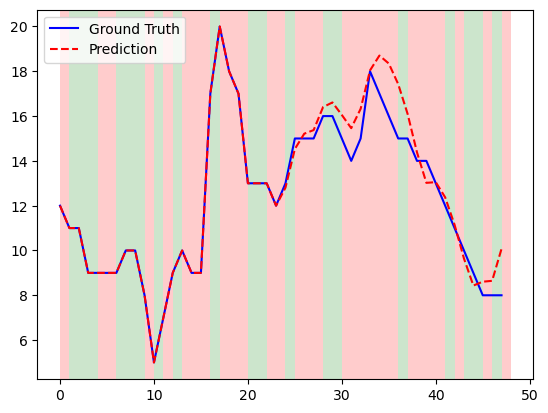

In [14]:
# 6. Visualization of one sample prediction
min_idx , max_idx = find_best_worst_se(Y_test,Y_pred)
print(f'Best: {min_idx}, Worst {max_idx}')
fig , ax = plt.subplots(1,1)
sample_idx = min_idx
aux.background_plotter(ax,np.hstack((X_test[sample_idx][PAST_W:-FUTURE_W],X_test[sample_idx][-FUTURE_W:])),sampling=1,stim_period=1)
ax.plot(range(PAST_W+FUTURE_W), np.hstack((X_test[sample_idx][:PAST_W],Y_test[sample_idx])), label='Ground Truth', color='blue')
ax.plot(range(PAST_W+FUTURE_W), np.hstack((X_test[sample_idx][:PAST_W],Y_pred[sample_idx])), label='Prediction', color='red', linestyle='--')
#plt.title(f"Future Prediction Window ({FUTURE_W} mins)")
#plt.xlabel("Minutes into future")
#plt.ylabel("y value")
ax.legend()
plt.show()

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 1. Data Preparation Class ---

class TimeSeriesDataset(Dataset):
    def __init__(self, u_data, y_data, past_window, future_window):
        """
        u_data: (N, 192)
        y_data: (N, 960)
        """
        self.past_window = past_window
        self.future_window = future_window
        
        # Upsample u to 960
        u_upsampled = u_data
        #u_upsampled = np.repeat(u_data, 5, axis=1)
        
        # Normalize y (Crucial for LSTMs)
        self.y_scaler = StandardScaler()
        y_scaled = self.y_scaler.fit_transform(y_data.reshape(-1, 1)).reshape(y_data.shape)
        
        X_past, X_future_u, Y_future = [], [], []
        
        for i in range(y_data.shape[0]):
            for t in range(past_window, y_data.shape[1] - future_window):
                # Encoder input: past (y, u) -> shape (past_window, 2)
                past_y = y_scaled[i, t - past_window : t].reshape(-1, 1)
                past_u = u_upsampled[i, t - past_window : t].reshape(-1, 1)
                X_past.append(np.hstack([past_y, past_u]))
                
                # Decoder input: future u -> shape (future_window, 1)
                X_future_u.append(u_upsampled[i, t : t + future_window].reshape(-1, 1))
                
                # Target: future y -> shape (future_window, 1)
                Y_future.append(y_scaled[i, t : t + future_window].reshape(-1, 1))

        self.X_past = torch.tensor(np.array(X_past), dtype=torch.float32)
        self.X_future_u = torch.tensor(np.array(X_future_u), dtype=torch.float32)
        self.Y_future = torch.tensor(np.array(Y_future), dtype=torch.float32)

    def __len__(self):
        return len(self.X_past)

    def __getitem__(self, idx):
        return self.X_past[idx], self.X_future_u[idx], self.Y_future[idx]

# --- 2. Model Architecture ---

class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_layers):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, n_layers, batch_first=True)
        
    def forward(self, x):
        # x: (batch, past_window, 2)
        outputs, (hidden, cell) = self.lstm(x)
        return hidden, cell

class Decoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, n_layers):
        super().__init__()
        # input_dim will be 1 (future u)
        self.lstm = nn.LSTM(input_dim, hidden_dim, n_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x, hidden, cell):
        # x: (batch, future_window, 1)
        # hidden/cell: from encoder
        outputs, (hidden, cell) = self.lstm(x, (hidden, cell))
        # outputs: (batch, future_window, hidden_dim)
        predictions = self.fc(outputs) 
        return predictions

class Seq2SeqLSTM(nn.Module):
    def __init__(self, hidden_dim, n_layers):
        super().__init__()
        self.encoder = Encoder(input_dim=2, hidden_dim=hidden_dim, n_layers=n_layers)
        self.decoder = Decoder(input_dim=1, hidden_dim=hidden_dim, output_dim=1, n_layers=n_layers)
        
    def forward(self, past_xy, future_u):
        hidden, cell = self.encoder(past_xy)
        predictions = self.decoder(future_u, hidden, cell)
        return predictions

# --- 3. Training and Evaluation Functions ---

def train_model(model, dataloader, epochs=10, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    
    for epoch in range(epochs):
        total_loss = 0
        for batch_past, batch_future_u, batch_y in dataloader:
            optimizer.zero_grad()
            output = model(batch_past, batch_future_u)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(dataloader):.6f}")

def evaluate(model, dataloader, scaler):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for batch_past, batch_future_u, batch_y in dataloader:
            output = model(batch_past, batch_future_u)
            all_preds.append(output.numpy())
            all_targets.append(batch_y.numpy())
            
    # Reshape and Inverse Scale
    preds = np.concatenate(all_preds).squeeze()
    targets = np.concatenate(all_targets).squeeze()
    
    # Scale back to original units
    preds_orig = scaler.inverse_transform(preds.reshape(-1, 1)).reshape(preds.shape)
    targets_orig = scaler.inverse_transform(targets.reshape(-1, 1)).reshape(targets.shape)
    
    mse = np.mean((preds_orig - targets_orig)**2)
    print(f"Test MSE: {mse:.4f}")
    return targets_orig, preds_orig


# Hyperparameters
PAST_W = 24
FUTURE_W = 24 # Predict next 12 minutes (or next 60, up to you)
HIDDEN_SIZE = 64
LAYERS = 2
BATCH_SIZE = 32

# Split experiments
u_train, u_test, y_train, y_test = train_test_split(u_sim, y_sim, test_size=0.2)

# Create Datasets
train_ds = TimeSeriesDataset(u_train, y_train, PAST_W, FUTURE_W)
test_ds = TimeSeriesDataset(u_test, y_test, PAST_W, FUTURE_W)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

# Initialize Model
model = Seq2SeqLSTM(hidden_dim=HIDDEN_SIZE, n_layers=LAYERS)

# Run Training
train_model(model, train_loader, epochs=100)

# Evaluate
y_true, y_pred = evaluate(model, test_loader, train_ds.y_scaler)

Epoch 1/100, Loss: 0.404644
Epoch 2/100, Loss: 0.361274
Epoch 3/100, Loss: 0.357849
Epoch 4/100, Loss: 0.353683
Epoch 5/100, Loss: 0.352670
Epoch 6/100, Loss: 0.351504
Epoch 7/100, Loss: 0.346562
Epoch 8/100, Loss: 0.345917
Epoch 9/100, Loss: 0.342671
Epoch 10/100, Loss: 0.338324
Epoch 11/100, Loss: 0.333072
Epoch 12/100, Loss: 0.325495
Epoch 13/100, Loss: 0.335641
Epoch 14/100, Loss: 0.325412
Epoch 15/100, Loss: 0.317336
Epoch 16/100, Loss: 0.303558
Epoch 17/100, Loss: 0.297348
Epoch 18/100, Loss: 0.284708
Epoch 19/100, Loss: 0.272124
Epoch 20/100, Loss: 0.262315
Epoch 21/100, Loss: 0.244004
Epoch 22/100, Loss: 0.228751
Epoch 23/100, Loss: 0.215465
Epoch 24/100, Loss: 0.210138
Epoch 25/100, Loss: 0.192335
Epoch 26/100, Loss: 0.178392
Epoch 27/100, Loss: 0.168501
Epoch 28/100, Loss: 0.160005
Epoch 29/100, Loss: 0.149810
Epoch 30/100, Loss: 0.155225
Epoch 31/100, Loss: 0.131746
Epoch 32/100, Loss: 0.124163
Epoch 33/100, Loss: 0.115933
Epoch 34/100, Loss: 0.110578
Epoch 35/100, Loss: 0.1

Best Sample Index: 5895 (MSE: 0.001877)
Worst Sample Index: 6395 (MSE: 13.712662)


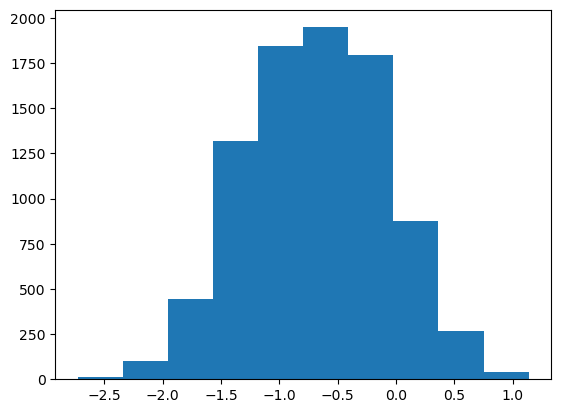

In [19]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Diagnostic Functions ---

def find_best_worst_indices(y_true, y_pred,plot=False):
    """
    Calculates the error for every individual sample window.
    y_true/y_pred: shape (N_samples, future_window, 1)
    """
    # Reshape to (N_samples, future_window) for calculation
    y_true_flat = y_true.reshape(y_true.shape[0], -1)
    y_pred_flat = y_pred.reshape(y_pred.shape[0], -1)
    
    # Calculate Mean Squared Error for each individual row (sample)
    sample_errors = np.mean((y_true_flat - y_pred_flat)**2, axis=1)
    
    best_idx = np.argmin(sample_errors)
    worst_idx = np.argmax(sample_errors)
    if plot:
        plt.hist(np.log10(sample_errors))
    print(f"Best Sample Index: {best_idx} (MSE: {sample_errors[best_idx]:.6f})")
    print(f"Worst Sample Index: {worst_idx} (MSE: {sample_errors[worst_idx]:.6f})")
    
    return best_idx, worst_idx

def get_test_sample_details(index, dataset, y_pred_all, scaler):
    """
    Retrieves and inverse-scales all components for a specific test sample.
    """
    # 1. Get raw tensors from the dataset
    # past_xy shape: (past_window, 2) -> col 0 is y, col 1 is u
    # future_u shape: (future_window, 1)
    # future_y_true shape: (future_window, 1)
    past_xy, future_u, future_y_true = dataset[index]
    
    # 2. Extract components
    past_y_scaled = past_xy[:, 0].numpy()
    past_u = past_xy[:, 1].numpy()
    future_u = future_u.numpy().flatten()
    future_y_true_scaled = future_y_true.numpy().flatten()
    future_y_pred_scaled = y_pred_all[index].flatten()
    
    # 3. Inverse scale the y-values to original units
    # Reshape for scaler (requires 2D)
    past_y = scaler.inverse_transform(past_y_scaled.reshape(-1, 1)).flatten()
    future_y_true = scaler.inverse_transform(future_y_true_scaled.reshape(-1, 1)).flatten()
    future_y_pred = scaler.inverse_transform(future_y_pred_scaled.reshape(-1, 1)).flatten()
    
    return {
        "past_y": past_y,
        "past_u": past_u,
        "future_u": future_u,
        "future_y_true": future_y_true,
        "future_y_pred": future_y_pred
    }
    
model.eval()
all_preds = []
all_trues = []
with torch.no_grad():
    for batch_past, batch_fut_u, batch_y in test_loader:
        out = model(batch_past, batch_fut_u)
        all_preds.append(out.numpy())
        all_trues.append(batch_y.numpy())

y_pred_test = np.concatenate(all_preds) # Shape: (N, future_window, 1)
y_true_test = np.concatenate(all_trues)

# B. Find the best and worst cases
best_i, worst_i = find_best_worst_indices(y_true_test, y_pred_test,plot=True)

# C. Get details and plot Best
best_details = get_test_sample_details(best_i, test_ds, y_pred_test, train_ds.y_scaler)
worst_details = get_test_sample_details(worst_i, test_ds, y_pred_test, train_ds.y_scaler)



In [ ]:

fig , ax = plt.subplots(1,1)
idx = best_i
sample = get_test_sample_details(idx,test_ds,y_pred_test,train_ds.y_scaler)

past_u = sample['past_u']
future_u = sample['future_u']
past_y = sample['past_y']
future_y_true = sample['future_y_true']
future_y_pred = sample['future_y_pred']



print(past_u.shape,future_u.shape)
aux.background_plotter(ax,np.hstack((past_u,future_u)),sampling=1,stim_period=1)
ax.plot(range(PAST_W+FUTURE_W), np.hstack((past_y,future_y_true)), label='Ground Truth', color='blue')
ax.plot(range(PAST_W+FUTURE_W), np.hstack((past_y,future_y_pred)), label='Prediction', color='red', linestyle='--')
#plt.title(f"Future Prediction Window ({FUTURE_W} mins)")
#plt.xlabel("Minutes into future")
#plt.ylabel("y value")
ax.legend()
plt.show()

NameError: name 'plt' is not defined

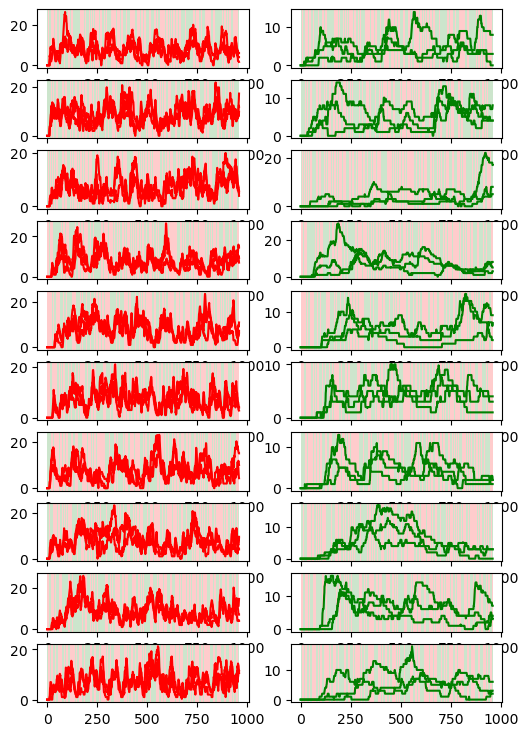

In [13]:
fig, ax = plt.subplots(10,2,figsize = (6,9))

for i in range(10):
    aux.background_plotter(ax[i][0],cells[f'{i+1}'].stims[0],averaged=True)
    aux.background_plotter(ax[i][1],cells[f'{i+1}'].stims[0],averaged=True)
    for j in range(num_realizations):        
        ax[i][1].plot(aux.average_stochastic_trace(cells[f'{i+1}'].expressions['F'][0][j,:]),color = 'green')
        ax[i][0].plot(aux.average_stochastic_trace(cells[f'{i+1}'].expressions['H'][0][j,:]), color = 'red')